# Lab 3: Contextual Bandit-Based News Article Recommendation System
## Part 1: Data Preprocessing and User Classification

**Student Roll Number:** U20230090  
**Name:** Lakshit Tyagi

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Pre-processing (10 Points)

### 1.1 Load Datasets

In [6]:
# Load the datasets
# Make sure the CSV files are in the correct path
train_users = pd.read_csv('data/train_users.csv')
test_users = pd.read_csv('data/test_users.csv')
news_articles = pd.read_csv('data/news_articles.csv')

print("Training Users Dataset Shape:", train_users.shape)
print("Test Users Dataset Shape:", test_users.shape)
print("News Articles Dataset Shape:", news_articles.shape)

Training Users Dataset Shape: (2000, 6)
Test Users Dataset Shape: (2000, 6)
News Articles Dataset Shape: (209527, 6)


### 1.2 Explore the Data

In [7]:
# Display first few rows of training data
print("\n=== Training Users Data ===")
print(train_users.head())
print("\nColumn Names:", train_users.columns.tolist())
print("\nData Types:")
print(train_users.dtypes)
print("\nMissing Values:")
print(train_users.isnull().sum())


=== Training Users Data ===
   user_id  age  income  clicks  purchase_amount  label
0        1   28   58242      81           378.38  user3
1        2   28   38225      21           114.50  user3
2        3   39   95017      41            66.24  user2
3        4   52   33473      98           496.88  user3
4        5   29   80690       5           293.24  user1

Column Names: ['user_id', 'age', 'income', 'clicks', 'purchase_amount', 'label']

Data Types:
user_id              int64
age                  int64
income               int64
clicks               int64
purchase_amount    float64
label               object
dtype: object

Missing Values:
user_id            0
age                0
income             0
clicks             0
purchase_amount    0
label              0
dtype: int64



=== User Category Distribution ===
label
user1    687
user2    669
user3    644
Name: count, dtype: int64


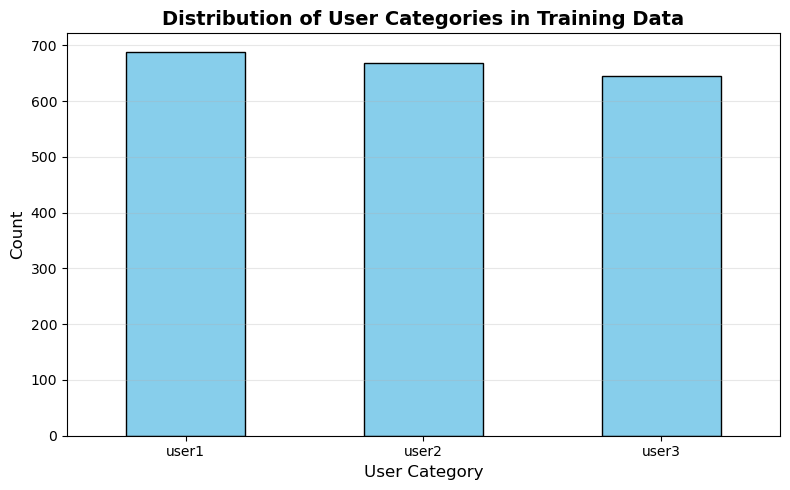

In [9]:
# Check the distribution of user categories
print("\n=== User Category Distribution ===")
print(train_users['label'].value_counts())  # Adjust column name if different

# Visualize the distribution
plt.figure(figsize=(8, 5))
train_users['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of User Categories in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('User Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 1.3 Data Cleaning and Preprocessing

In [15]:
# Function to preprocess user data
def preprocess_user_data(df, is_train=True):
    """
    Preprocess user data:
    - Handle missing values
    - Encode categorical features
    - Scale numerical features
    """
    df = df.copy()
    
    # Separate features and target (if training data)
    if is_train and 'label' in df.columns:
        X = df.drop(['label', 'user_id'], axis=1)  # Drop both label and user_id
        y = df['label'].copy()  # Make a copy
    else:
        X = df.drop('user_id', axis=1) if 'user_id' in df.columns else df.copy()
        y = None
    
    # Handle missing values
    # For numerical columns: fill with median
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].median(), inplace=True)
    
    # For categorical columns: fill with mode
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if X[col].isnull().sum() > 0:
            X[col].fillna(X[col].mode()[0], inplace=True)
    
    return X, y

# Preprocess training and test data
X_train, y_train = preprocess_user_data(train_users, is_train=True)
X_test, y_test = preprocess_user_data(test_users, is_train=True)

# Verify y_train and y_test are not None
print("\nAfter preprocessing:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape if y_train is not None else "None")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape if y_test is not None else "None")
print("\nFeatures:", X_train.columns.tolist())
print("\nTarget distribution in y_train:")
print(y_train.value_counts())
print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())


After preprocessing:
X_train shape: (2000, 4)
y_train shape: (2000,)
X_test shape: (2000, 4)
y_test shape: (2000,)

Features: ['age', 'income', 'clicks', 'purchase_amount']

Target distribution in y_train:
label
user1    687
user2    669
user3    644
Name: count, dtype: int64

Missing values in X_train: 0
Missing values in X_test: 0


### 1.4 Feature Encoding

In [18]:
# Encode categorical features
label_encoders = {}
categorical_cols = X_train.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    for col in categorical_cols:
        le = LabelEncoder()
        # Fit on training data
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        label_encoders[col] = le
        
        # Transform test data
        # Handle unseen categories by replacing them with a default value
        X_test[col] = X_test[col].astype(str)
        X_test[col] = X_test[col].apply(lambda x: x if x in le.classes_ else le.classes_[0])
        X_test[col] = le.transform(X_test[col])
    
    print("\nCategorical columns encoded:", list(categorical_cols))
else:
    print("\nNo categorical columns to encode (all features are numerical)")

print("\nX_train data types after encoding:")
print(X_train.dtypes)


No categorical columns to encode (all features are numerical)

X_train data types after encoding:
age                  int64
income               int64
clicks               int64
purchase_amount    float64
dtype: object


### 1.5 Feature Scaling

In [19]:
# Scale features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("\nFeature scaling completed!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Feature scaling completed!
X_train_scaled shape: (2000, 4)
X_test_scaled shape: (2000, 4)


## 2. User Classification (10 Points)

### 2.1 Train Classification Models

In [20]:
# Final verification before training
print("=== Final Check Before Training ===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train type: {type(y_train)}")
print(f"y_train is None: {y_train is None}")
print(f"\nUnique labels in y_train: {y_train.unique()}")
print(f"Label counts:\n{y_train.value_counts()}")

=== Final Check Before Training ===
X_train shape: (2000, 4)
y_train shape: (2000,)
y_train type: <class 'pandas.core.series.Series'>
y_train is None: False

Unique labels in y_train: ['user3' 'user2' 'user1']
Label counts:
label
user1    687
user2    669
user3    644
Name: count, dtype: int64



Training Decision Tree...

Accuracy: 0.3285

Classification Report:
              precision    recall  f1-score   support

       user1       0.32      0.30      0.31       672
       user2       0.33      0.33      0.33       679
       user3       0.34      0.36      0.35       649

    accuracy                           0.33      2000
   macro avg       0.33      0.33      0.33      2000
weighted avg       0.33      0.33      0.33      2000


Training Logistic Regression...

Accuracy: 0.3295

Classification Report:
              precision    recall  f1-score   support

       user1       0.35      0.50      0.41       672
       user2       0.32      0.36      0.34       679
       user3       0.29      0.13      0.18       649

    accuracy                           0.33      2000
   macro avg       0.32      0.33      0.31      2000
weighted avg       0.32      0.33      0.31      2000


Training Random Forest...

Accuracy: 0.3175

Classification Report:
              precision  

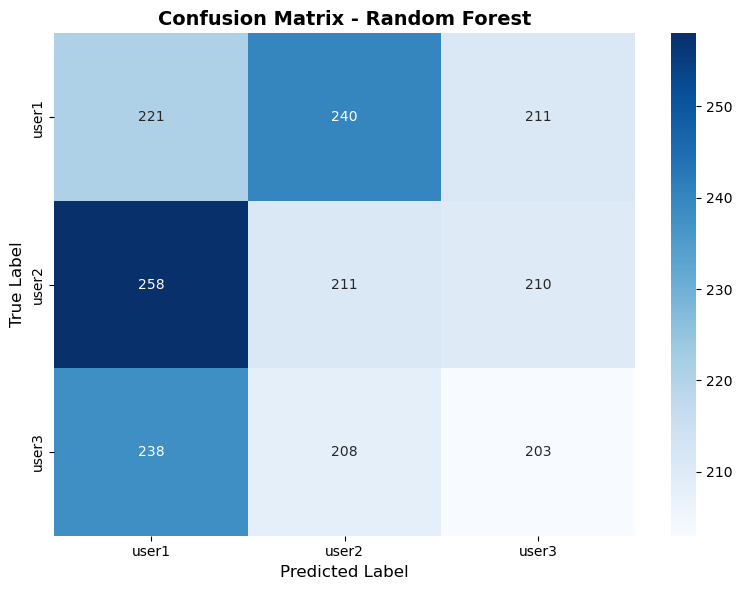

In [21]:
# Initialize different classifiers
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate each classifier
results = {}

for name, clf in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")
    
    # Train the model
    clf.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = clf.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['user1', 'user2', 'user3'],  # lowercase!
            yticklabels=['user1', 'user2', 'user3'])  # lowercase!
plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

### 2.2 Model Comparison


=== Model Comparison ===
Decision Tree: 0.3285
Logistic Regression: 0.3295
Random Forest: 0.3175


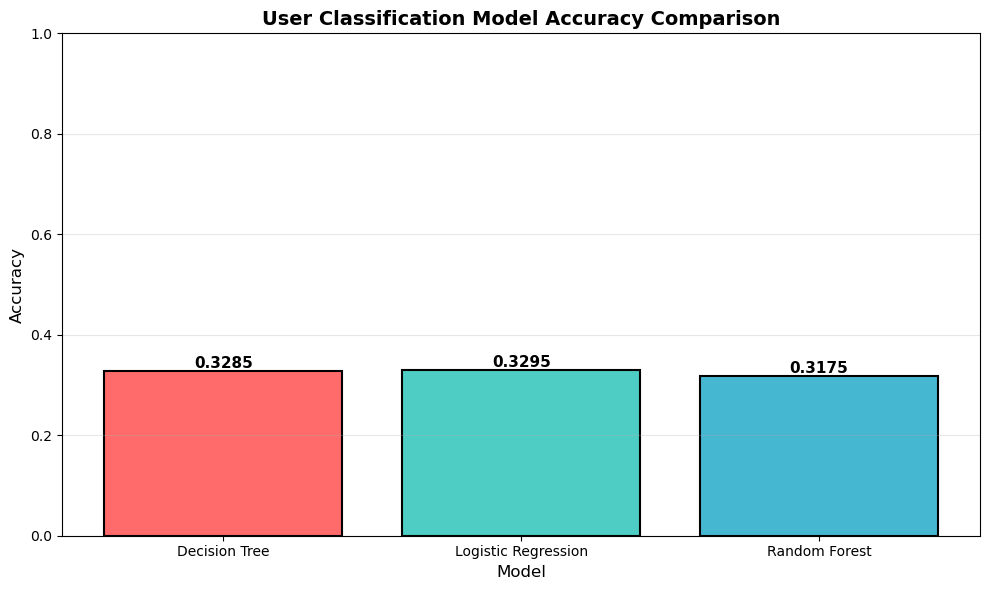


Best Model: Logistic Regression with accuracy 0.3295


In [22]:
# Compare model performances
print("\n=== Model Comparison ===")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
models = list(results.keys())
accuracies = list(results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.title('User Classification Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1.0])
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Select the best model
best_model_name = max(results, key=results.get)
best_model = classifiers[best_model_name]
print(f"\nBest Model: {best_model_name} with accuracy {results[best_model_name]:.4f}")

### 2.3 Save the Best Model (Optional)

In [23]:
import pickle

# Save the best model and preprocessing objects
with open('user_classifier.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

print("\nModel and preprocessing objects saved successfully!")


Model and preprocessing objects saved successfully!


## Summary

### Data Preprocessing
- Loaded training and test user datasets
- Handled missing values using median (numerical) and mode (categorical)
- Encoded categorical features using LabelEncoder
- Scaled features using StandardScaler

### User Classification
- Trained three different classifiers: Decision Tree, Logistic Regression, and Random Forest
- Evaluated models on test dataset
- Selected the best performing model based on accuracy

### Results
*(Add your specific results here after running the code)*

- Best Model: [Logistic Regression]
- Test Accuracy: [0.3295]

This classifier will serve as the **Context Detector** for the contextual bandit system in the next phase of the assignment.